Jumlah Baris dan Kolom:
(768, 9)

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Statistik Deskriptif:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI           

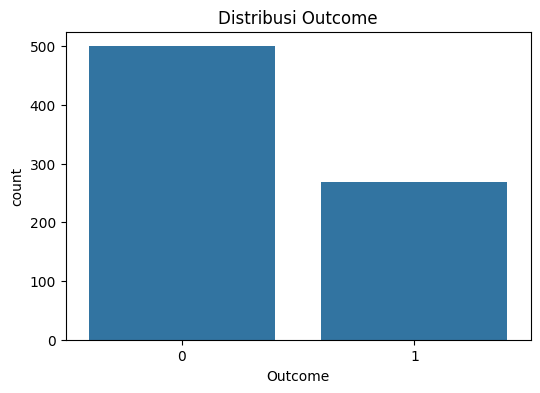

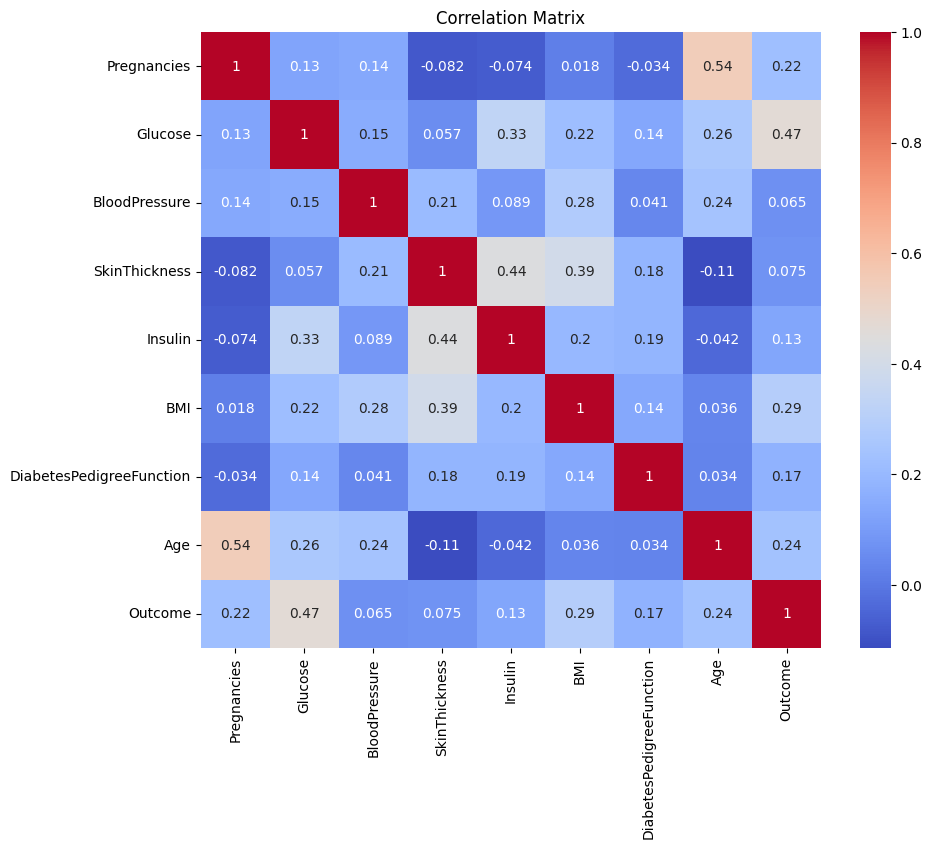

(768, 8)
(768,)
Data Train : (614, 8)
Data Test  : (154, 8)
Accuracy : 72.08 %
              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



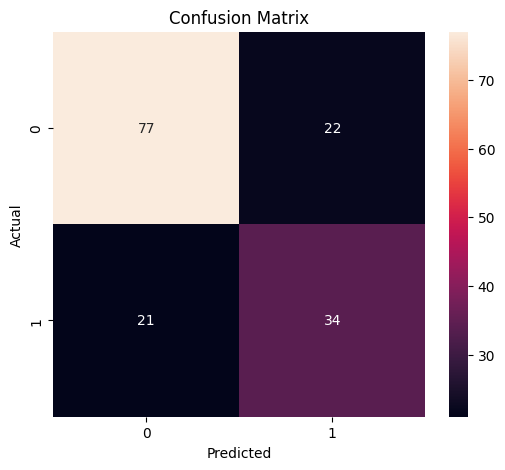

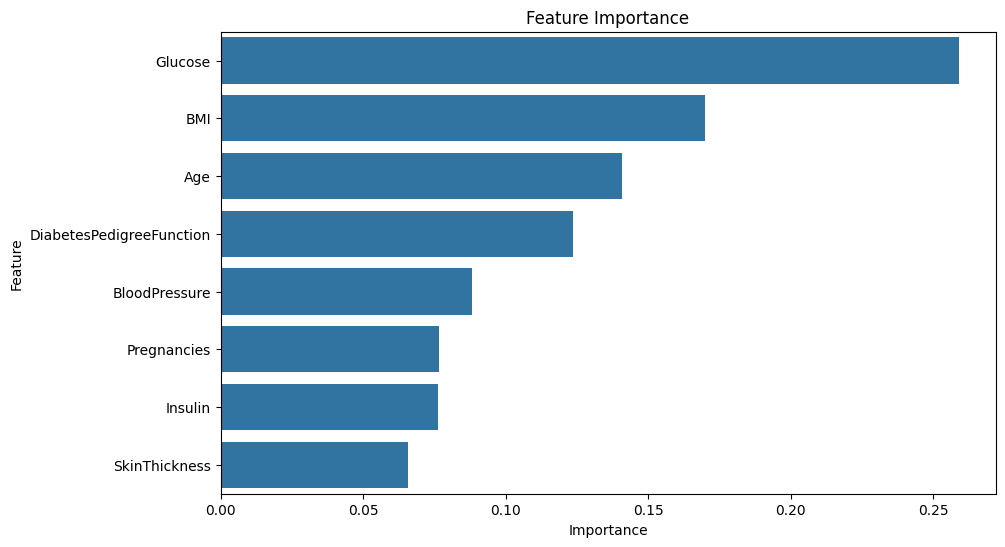

Model berhasil disimpan
Berisiko Diabetes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Accuracy XGBoost: 0.7207792207792207


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import pickle
df = pd.read_csv('diabetes.csv')

df.head()
print("Jumlah Baris dan Kolom:")
print(df.shape)

print("\nInformasi Dataset:")
df.info()

print("\nStatistik Deskriptif:")
df.describe()
print(df.isnull().sum())
print("Jumlah Data Duplikat:", df.duplicated().sum())
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df)

plt.title('Distribusi Outcome')
plt.show()
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print(X.shape)
print(y.shape)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data Train :", X_train.shape)
print("Data Test  :", X_test.shape)
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy*100,2), "%")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')
plt.show()
pickle.dump(
    rf_model,
    open('model.pkl', 'wb')
)

print("Model berhasil disimpan")
sample = [[
    6,
    148,
    72,
    35,
    0,
    33.6,
    0.627,
    50
]]

hasil = rf_model.predict(sample)

if hasil[0] == 1:
    print("Berisiko Diabetes")
else:
    print("Tidak Berisiko Diabetes")
!pip install xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier()

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

print(
    "Accuracy XGBoost:",
    accuracy_score(y_test, pred_xgb)
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')